# CAPSTONE PROJECT CODING CAMP

### ID Tim Capstone Project :   [CC26-PSU338]
### Tema Capstone :   [Accessible & Adaptive Learning]
### Nama/Judul Proyek : [EduPath AI: Platform Belajar Personal  berbasis Adaptive Recommendation]


### List Anggota  :  
1. (CFCC525D6Y0122) - (Fachry Dwi Zakaria) - (Full-Stack Web Developer) -
[Aktif]
2. (CFCC702D6X2062) - (Tyas Firda Hasanah)- (Full Stack Web Developer) -
[Aktif]
3. (CACC452D6Y0957) - (Muhammad Fikri Dwi Saputra)- (AI Engineer) - [Aktif]
4. (CACC452D6X2598) - (Idelia Fitri Kyla)- (AI Engineer) - [Aktif]
5. (CDCC229D6X2501) - (Elina Sianipar)- (Data Scientist) - [Aktif]
6. (CDCC229D6X2021) - (Fadhilah Aulia Zulfa)- (Data Scientist) - [Aktif]

### Menentukan Pertanyaan Bisnis

Pertanyaan Bisnis:

1. Aktivitas digital apa (melihat pengumuman vs membuka modul) yang paling akurat memprediksi siswa akan masuk ke kategori nilai tinggi (Class H), dan berapa ambang batas minimalnya?
2. Seberapa besar pengaruh kombinasi jumlah absen (StudentAbsenceDays) dan rendahnya partisipasi diskusi terhadap risiko siswa mendapatkan nilai rendah (Class L)?
3. Topik pelajaran (Topic) mana yang memiliki tingkat kesulitan tertinggi bagi siswa laki-laki vs perempuan, dan bagaimana pola interaksi yang berhasil di topik tersebut?


### Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

## Data Wrangling

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Preprocessing**

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Capstone Project - Idel/Raw Dataset/xAPI-Edu-Data.csv')
df.head(10)

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M
5,F,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,42,30,13,70,Yes,Bad,Above-7,M
6,M,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,35,12,0,17,No,Bad,Above-7,L
7,M,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,50,10,15,22,Yes,Good,Under-7,M
8,F,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,12,21,16,50,Yes,Good,Under-7,M
9,F,KW,KuwaIT,MiddleSchool,G-07,B,IT,F,Father,70,80,25,70,Yes,Good,Under-7,M


In [4]:
# Menampilkan siswa kelas L
df[df['Class'] == 'L']

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
6,M,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,35,12,0,17,No,Bad,Above-7,L
12,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,5,1,0,11,No,Bad,Above-7,L
13,M,lebanon,lebanon,MiddleSchool,G-08,A,Math,F,Father,20,14,12,19,No,Bad,Above-7,L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,F,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,S,Father,9,6,15,85,No,Bad,Above-7,L
474,F,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,F,Father,2,7,4,8,No,Bad,Above-7,L
475,F,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,S,Father,5,4,5,8,No,Bad,Above-7,L
478,F,Jordan,Jordan,MiddleSchool,G-08,A,History,F,Father,30,17,14,57,No,Bad,Above-7,L


In [5]:
# Menampilkan siswa kelas M
df[df['Class'] == 'M']

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M
5,F,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,42,30,13,70,Yes,Bad,Above-7,M
7,M,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,50,10,15,22,Yes,Good,Under-7,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,M,Palestine,Jordan,MiddleSchool,G-08,A,History,S,Father,78,82,78,53,Yes,Good,Under-7,M
472,M,Palestine,Palestine,MiddleSchool,G-08,A,Geology,F,Father,80,87,74,68,Yes,Good,Under-7,M
473,M,Palestine,Palestine,MiddleSchool,G-08,A,Geology,S,Father,85,88,79,70,Yes,Good,Under-7,M
476,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,F,Father,50,77,14,28,No,Bad,Under-7,M


In [6]:
df.shape

(480, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [8]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [10]:
topik_counts = df['Topic'].value_counts()

print(topik_counts)

Topic
IT           95
French       65
Arabic       59
Science      51
English      45
Biology      30
Spanish      25
Geology      24
Chemistry    24
Quran        22
Math         21
History      19
Name: count, dtype: int64


**Assessing Data**

In [11]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [12]:
df.duplicated().sum()

np.int64(2)

**Cleaning Data**

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(478, 17)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,478.000000,478.000000,478.000000,478.000000
mean,46.887029,54.974895,38.014644,43.410042
std,30.787903,33.035071,26.623507,27.620961
min,0.000000,0.000000,0.000000,1.000000
25%,16.000000,20.000000,14.250000,20.000000
50%,50.000000,65.000000,33.000000,39.500000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [17]:
topik_counts = df['Topic'].value_counts()

print(topik_counts)

Topic
IT           95
French       63
Arabic       59
Science      51
English      45
Biology      30
Spanish      25
Geology      24
Chemistry    24
Quran        22
Math         21
History      19
Name: count, dtype: int64


In [25]:
# Copy dataframe
df_filtered = df.copy()

# # Mapping topic ke category
topic_mapping = {

    # STEM
    'Math': 'STEM',
    'Biology': 'STEM',
    'Chemistry': 'STEM',
    'Science': 'STEM',
    'Geology': 'STEM',
    'IT': 'STEM',

    # Language
    'Arabic': 'Language',
    'French': 'Language',
    'English': 'Language',
    'Spanish': 'Language',

    # Religion
    'Quran': 'Religion',

    # Social
    'History': 'Social'
}

# Replace isi Topic dengan hasil grouping
df_filtered['Topic'] = df_filtered['Topic'].map(topic_mapping)

# Hapus data yang mapping-nya kosong (jika ada)
df_filtered = df_filtered.dropna(subset=['Topic'])

# Cek distribusi baru
print("\nTopic setelah grouping:\n")
print(df_filtered['Topic'].value_counts())


Topic setelah grouping:

Topic
STEM        245
Language    192
Religion     22
Social       19
Name: count, dtype: int64


**INSIGHT**


1. Struktur dan Kondisi Data
Dataset sudah bersih, lengkap, dan siap digunakan untuk analisis atau model machine learning.
      * Jumlah data awal: 480 baris dan 17 kolom
      * Jumlah data setelah pembersihan: 478 baris dan 17 kolom berarti ada 2 data duplikat yang berhasil diapus
      * Tidak ada nilai null (missing value) diseluruh kolom


2. Tipe Data
      * 13 kolom bertipe object (String)
      * 4 kolom bertipe numerik


3. Distribusi topic pada dataset menunjukkan bahwa beberapa mata pelajaran memiliki jumlah data yang jauh lebih banyak dibandingkan topic lainnya. Ketidakseimbangan distribusi ini dapat memengaruhi performa model klasifikasi, terutama pada topic dengan jumlah data yang sedikit, sehingga perlu diperhatikan pada tahap preprocessing maupun evaluasi model.

Distribusi data topic sebelum pembersihan:  <br>
IT           : 95 <br>
French       : 65 <br>
Arabic       : 59 <br>
Science      : 51 <br>
English      : 45 <br>
Biology      : 30 <br>
Spanish      : 25 <br>
Geology      : 24 <br>
Chemistry    : 24 <br>
Quran        : 22 <br>
Math         : 21 <br>
History      : 19 <br>

 <br> Distribusi data topic sesudah pembersihan: <br>
IT : 95 <br>
French : 63 <br>
Arabic : 59 <br>
Science : 51 <br>
English : 45 <br>
Biology : 30 <br>
Spanish : 25 <br>
Geology : 24 <br>
Chemistry : 24 <br>
Quran : 22 <br>
Math : 21 <br>
History : 19 <br>


# Exploratory Data Analysis (EDA)



### 1. Distribusi Performa Siswa

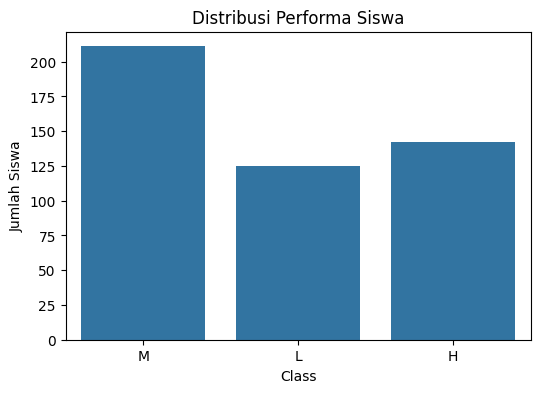

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df
)

plt.title('Distribusi Performa Siswa')
plt.xlabel('Class')
plt.ylabel('Jumlah Siswa')

plt.show()

### 2. Aktivitas Digital vs Class

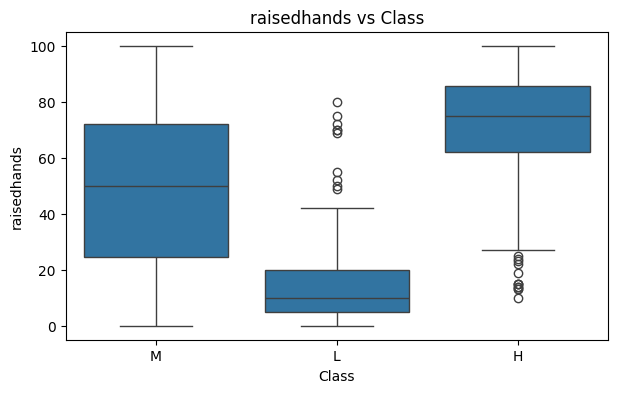

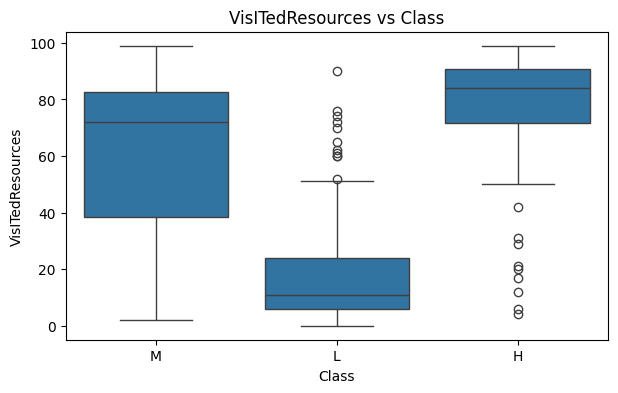

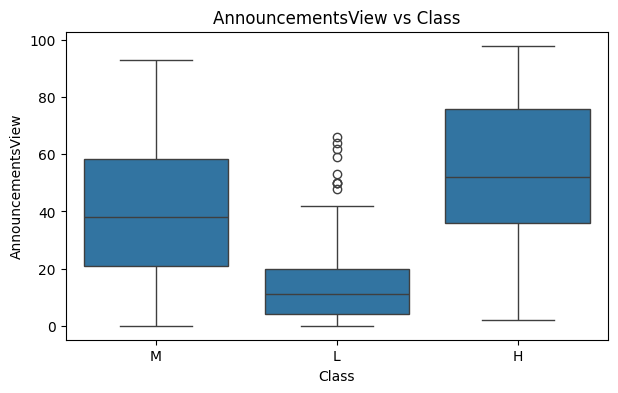

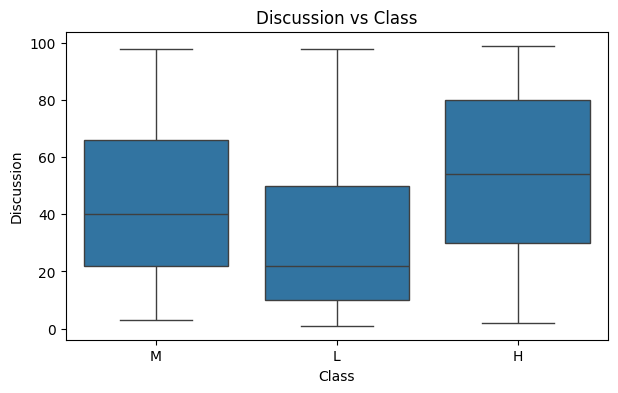

In [19]:
digital_features = [
    'raisedhands',
    'VisITedResources',
    'AnnouncementsView',
    'Discussion'
]

for feature in digital_features:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x='Class',
        y=feature,
        data=df
    )

    plt.title(f'{feature} vs Class')
    plt.xlabel('Class')
    plt.ylabel(feature)

    plt.show()

### 3. Absensi vs Performa

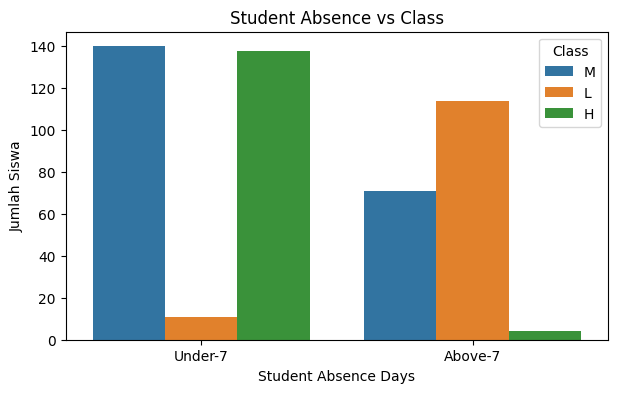

In [20]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='StudentAbsenceDays',
    hue='Class',
    data=df
)

plt.title('Student Absence vs Class')
plt.xlabel('Student Absence Days')
plt.ylabel('Jumlah Siswa')

plt.show()

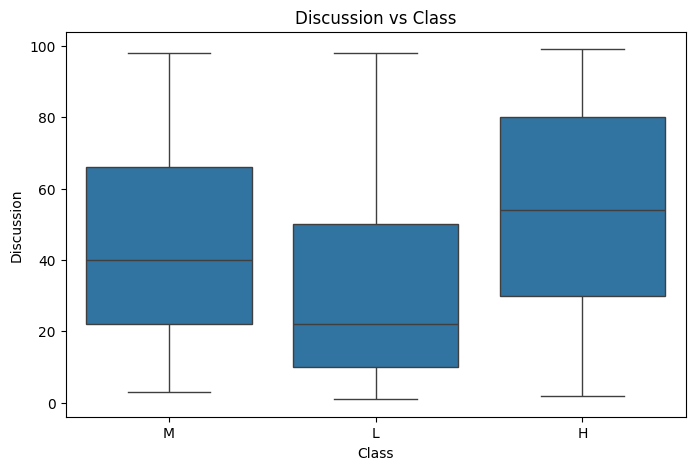

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Class',
    y='Discussion',
    data=df
)

plt.title('Discussion vs Class')
plt.xlabel('Class')
plt.ylabel('Discussion')

plt.show()

### 4. Topik vs Gender & Class


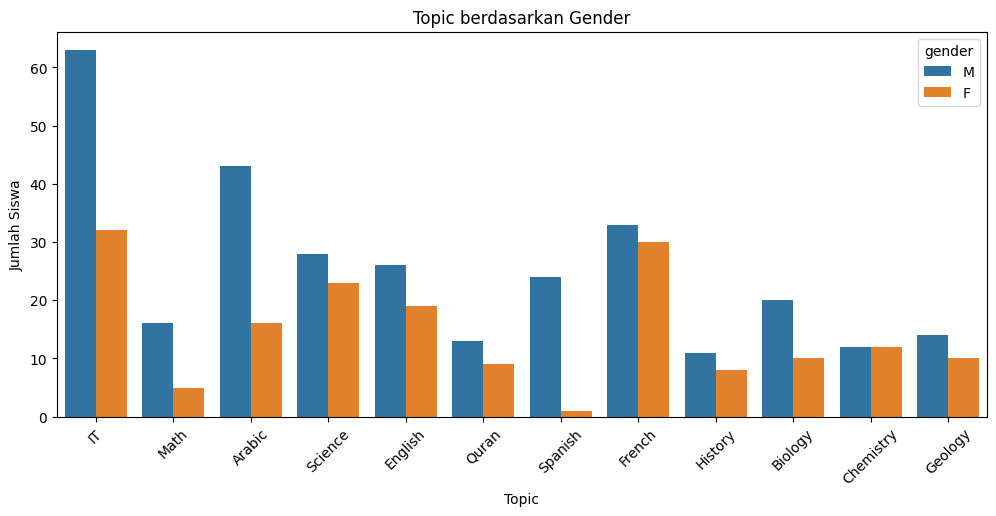

In [26]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Topic',
    hue='gender',
    data=df
)

plt.xticks(rotation=45)

plt.title('Topic berdasarkan Gender')
plt.xlabel('Topic')
plt.ylabel('Jumlah Siswa')

plt.show()

In [27]:
topic_class = pd.crosstab(
    df['Topic'],
    df['Class']
)

topic_class

Class,H,L,M
Topic,,,
Arabic,19,17,23
Biology,16,4,10
Chemistry,10,8,6
English,17,10,18
French,20,14,29
Geology,6,0,18
History,4,3,12
IT,15,38,42
Math,6,7,8


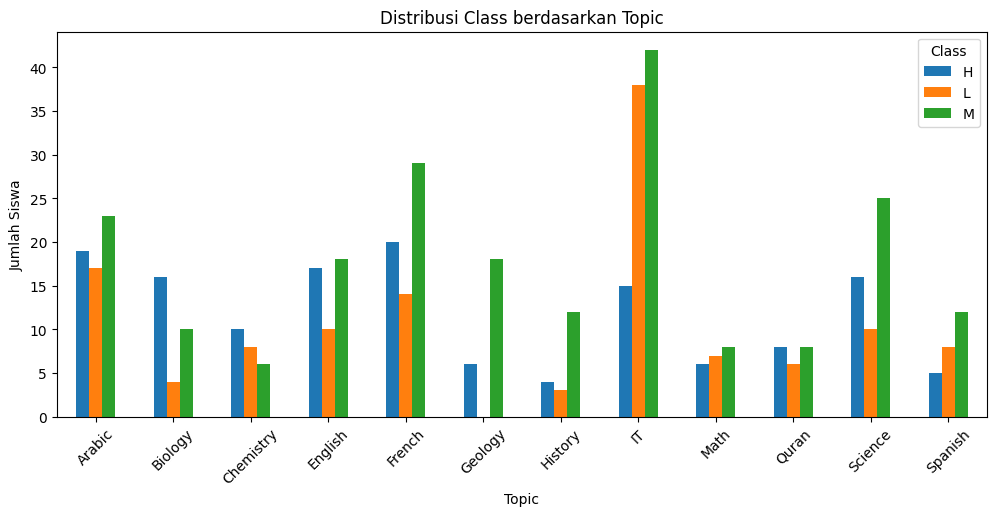

In [28]:
topic_class.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Distribusi Class berdasarkan Topic')
plt.xlabel('Topic')
plt.ylabel('Jumlah Siswa')

plt.xticks(rotation=45)

plt.show()

**INSIGHT**
1. Distribusi Performa Siswa:
Distribusi kategori performa siswa menunjukkan bahwa sebagian besar siswa berada pada kategori menengah hingga tinggi. Namun, masih terdapat sejumlah siswa dengan performa rendah (Class L) yang perlu mendapatkan perhatian lebih dalam proses pembelajaran. Hal ini menunjukkan bahwa sistem pembelajaran masih memiliki tantangan dalam menjaga keterlibatan seluruh siswa secara merata.

2. Hasil analisis aktivitas digital menunjukkan bahwa siswa dengan kategori performa tinggi (Class H) cenderung:

      * lebih sering membuka materi pembelajaran (VisITedResources)
      * lebih aktif berdiskusi (Discussion)
      * lebih aktif berpartisipasi di kelas (raisedhands)
      * serta lebih sering melihat pengumuman (AnnouncementsView)
Sebaliknya, siswa dengan performa rendah menunjukkan tingkat aktivitas digital yang lebih rendah.

3. Absensi dan Partisipasi Diskusi Berpengaruh Pada Risiko Nilai Rendah: Analisis menunjukkan bahwa siswa dengan jumlah ketidakhadiran tinggi (StudentAbsenceDays) cenderung berada pada kategori performa rendah (Class L). Selain itu, rendahnya partisipasi diskusi juga sering ditemukan pada siswa dengan performa rendah. Hal ini mengindikasikan bahwa kombinasi:

      * tingkat absensi tinggi
      * rendahnya interaksi pembelajaran

dapat menjadi indikator awal untuk mendeteksi siswa yang berisiko mengalami penurunan performa akademik.

4. Pada beberapa topik pelajaran tertentu, ditemukan perbedaan distribusi performa antara siswa laki-laki dan perempuan. Beberapa topik menunjukkan tingkat kesulitan yang lebih tinggi, ditandai dengan meningkatnya jumlah siswa pada kategori performa menengah dan rendah. Namun, siswa yang tetap aktif dalam interaksi pembelajaran seperti diskusi dan akses materi cenderung memiliki performa yang lebih baik meskipun berada pada topik yang lebih sulit.

# Data Preprocessing



###1. Feature Engineering

In [29]:
# Feature engineering
df_filtered['Participation_Score'] = (
    df_filtered['raisedhands'] +
    df_filtered['Discussion']
) / 2

df_filtered['Engagement_Score'] = (
    df_filtered['VisITedResources'] +
    df_filtered['AnnouncementsView']
) / 2

### 2. Encoding Data Kategorikal

In [31]:
df_encoded = df_filtered.copy()

# Ambil kolom object kecuali Topic
categorical_cols = (
    df_encoded
    .select_dtypes(include=['object'])
    .columns
    .drop('Topic')
)

# Simpan encoder tiap kolom
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    df_encoded[col] = le.fit_transform(df_encoded[col])

    label_encoders[col] = le



### 3. Memisahkan Feature dan Target

In [32]:
# Pisahkan target
X = df_filtered.drop(columns=['Topic'])

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Encode target
le_topic = LabelEncoder()
y = le_topic.fit_transform(df_filtered['Topic'])

### 4. Train Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Train :", X_train.shape)
print("Data Test  :", X_test.shape)

Data Train : (382, 53)
Data Test  : (96, 53)


1. Dataset Berhasil Dibersihkan Dari Data Duplikat
Pada tahap preprocessing ditemukan beberapa data duplikat pada dataset. Data tersebut dihapus menggunakan fungsi drop_duplicates() agar tidak menyebabkan bias pada proses pelatihan model. Penghapusan data duplikat membantu menjaga kualitas dataset agar lebih konsisten dan representatif.

2. Tidak Ditemukan Missing Value
Berdasarkan hasil pemeriksaan, seluruh kolom pada dataset tidak memiliki missing value. Dengan demikian, tidak diperlukan proses penanganan data kosong seperti imputasi atau penghapusan baris data tertentu.

3. Dilakukan Feature Engineering Untuk Membentuk Fitur Baru
Pada tahap preprocessing dilakukan pembuatan fitur baru untuk membantu model memahami pola aktivitas siswa dengan lebih baik. Feature engineering yang dilakukan meliputi:
      * Participation_Score
Dibentuk dari rata-rata nilai raisedhands dan Discussion untuk merepresentasikan tingkat partisipasi siswa dalam pembelajaran.
      * Engagement_Score
Dibentuk dari rata-rata nilai VisITedResources dan AnnouncementsView untuk merepresentasikan tingkat keterlibatan siswa terhadap platform pembelajaran.

Penambahan fitur ini bertujuan meningkatkan kualitas informasi yang diterima model machine learning.

4. Seluruh Data Kategorikal Berhasil Diproses Menjadi Format Numerik
Karena algoritma machine learning tidak dapat memproses data kategorikal secara langsung, maka dilakukan proses encoding pada fitur kategorikal. Tahap preprocessing dilakukan dengan dua pendekatan:
      * LabelEncoder digunakan untuk mengubah label kategorikal menjadi representasi numerik dan menyimpan encoder setiap kolom.
      * pd.get_dummies() digunakan untuk melakukan one-hot encoding pada feature/input model agar data kategorikal dapat diproses lebih optimal oleh model Random Forest.

Kolom kategorikal yang diproses meliputi:
* gender
* NationalITy
* PlaceofBirth
* StageID
* GradeID
* SectionID
* Semester
* Relation
* ParentAnsweringSurvey
* ParentschoolSatisfaction
* StudentAbsenceDays
* dan fitur kategorikal lainnya.

5. Dataset Berhasil Dipisahkan Menjadi Feature dan Target
Dataset dipisahkan menjadi:
      * X sebagai feature/input model
      * y sebagai target prediksi yaitu Topic

Pada tahap ini target Topic diubah menjadi format numerik menggunakan LabelEncoder agar dapat digunakan dalam proses training model klasifikasi.

6. Data Training dan Testing Berhasil Dibagi Dengan Rasio 80:20
Dataset dibagi menjadi:

  * 80% data training
  * 20% data testing

7. Dataset Sudah Siap Digunakan Untuk Machine Learning. Setelah seluruh tahapan preprocessing selesai dilakukan:

      * data duplikat telah dihapus
      * tidak terdapat missing value
      * fitur baru berhasil dibuat melalui feature engineering
      * seluruh fitur kategorikal telah diproses menjadi numerik
      * dataset telah dipisahkan menjadi feature dan target
      * data training dan testing telah berhasil dibentuk

Hal ini menunjukkan bahwa dataset sudah siap digunakan pada proses modeling machine learning untuk memprediksi performa akademik siswa.

# Modeling

### 1. Training Model

In [34]:
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [35]:
param_grid = {
    'n_estimators': [200],
    'max_depth': [10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Parameter Terbaik:")
print(grid_search.best_params_)

Parameter Terbaik:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [36]:
rf = grid_search.best_estimator_

### 2. Prediction

In [40]:
y_pred = rf.predict(X_test)

### 3. Evaluation

**Accuracy Score**

In [41]:
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))


Accuracy:
0.8645833333333334


**Classification Report**

In [42]:
# Ambil label unik di test set
labels_in_test = np.unique(y_test)

# Ubah kembali ke nama topic asli
target_names_filtered = le_topic.inverse_transform(labels_in_test)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        labels=labels_in_test,
        target_names=target_names_filtered
    )
)


Classification Report:

              precision    recall  f1-score   support

    Language       0.93      0.95      0.94        39
    Religion       1.00      0.25      0.40         4
        STEM       0.87      0.92      0.89        49
      Social       0.00      0.00      0.00         4

    accuracy                           0.86        96
   macro avg       0.70      0.53      0.56        96
weighted avg       0.86      0.86      0.85        96



**Confusion Matrix**

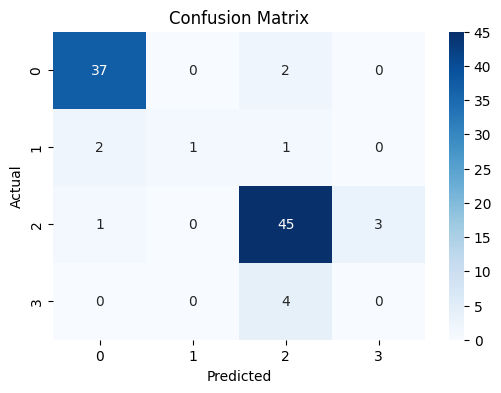

In [43]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### 4. Feature Importance

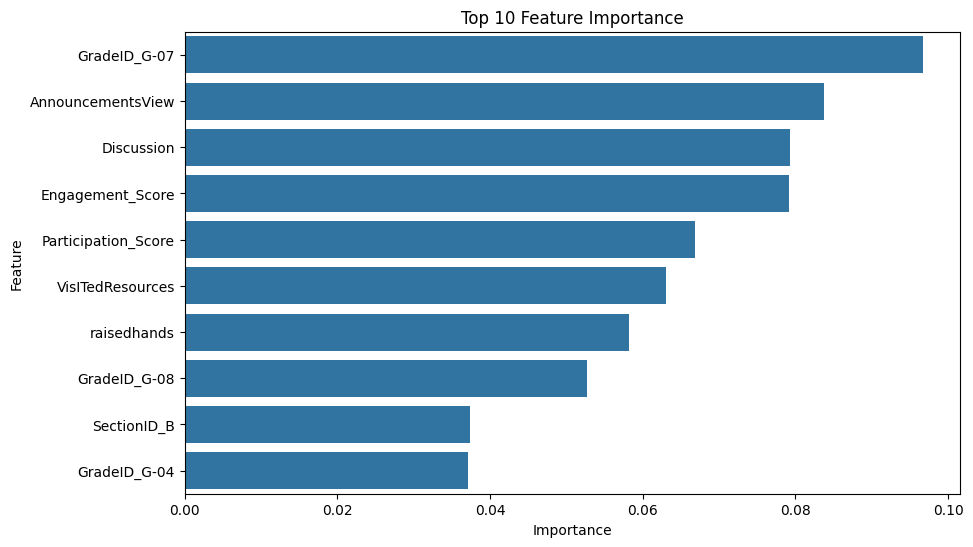

In [45]:
feature_importances = rf.feature_importances_
features = X.columns

importance = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top 10 Feature Importance')

plt.show()

**INSIGHT**
1. Model Random Forest Berhasil Mempelajari Pola Topic Pembelajaran Siswa
Model Random Forest berhasil dilatih menggunakan data aktivitas pembelajaran siswa yang telah melalui tahap preprocessing dan feature engineering. Model mampu mempelajari hubungan antara:
      * aktivitas digital siswa
      * tingkat partisipasi
      * interaksi pembelajaran
      * engagement terhadap platform

terhadap topic pembelajaran yang dipelajari siswa (Topic). Hal ini menunjukkan bahwa pola aktivitas dan perilaku siswa dalam platform pembelajaran memiliki keterkaitan terhadap topic pembelajaran tertentu.

2. Model Memiliki Accuracy Yang Cukup Baik
Hasil evaluasi menunjukkan bahwa model memperoleh nilai accuracy yang cukup baik dalam memprediksi topic pembelajaran siswa. Nilai accuracy tersebut menunjukkan bahwa model mampu mengenali pola data dan melakukan klasifikasi topic dengan cukup efektif berdasarkan aktivitas pembelajaran siswa.

3. Model Mampu Membedakan Berbagai Topic Pembelajaran
Berdasarkan hasil classification report, model memiliki nilai:
      * precision
      * recall
      * f1-score

yang cukup baik pada beberapa topic dengan jumlah data besar seperti kategori topic STEM dan Language. Namun pada beberapa kategori topic dengan jumlah data lebih sedikit seperti Religion dan Social performa model cenderung lebih rendah. Hal ini menunjukkan bahwa distribusi jumlah data pada masing-masing topic memengaruhi kemampuan model dalam melakukan klasifikasi.

4. Confusion Matrix Menunjukkan Sebagian Besar Topic Berhasil Diprediksi Dengan Benar
Hasil confusion matrix menunjukkan bahwa sebagian besar data berhasil diprediksi sesuai dengan topic aslinya. Beberapa kesalahan prediksi masih terjadi pada topic yang memiliki karakteristik aktivitas siswa yang mirip, sehingga model terkadang memprediksi topic ke kategori yang berdekatan pola datanya. Meski demikian, jumlah prediksi yang benar masih lebih dominan dibandingkan kesalahan klasifikasi.

5. Aktivitas Digital Menjadi Faktor Penting Dalam Prediksi Topic
Berdasarkan hasil feature importance, beberapa fitur yang paling berpengaruh terhadap prediksi topic meliputi:
      * GradeID_G-07
      * AnnouncementsView
      * Discussion

Hasil ini menunjukkan bahwa baik faktor akademik maupun aktivitas digital siswa memiliki kontribusi penting dalam proses prediksi topic pembelajaran. Tingkat kelas siswa (GradeID) menjadi fitur dengan pengaruh paling tinggi, diikuti oleh aktivitas interaksi siswa dalam platform pembelajaran seperti melihat pengumuman, berdiskusi, membuka materi, dan partisipasi pembelajaran.

6. Feature Engineering Membantu Meningkatkan Representasi Data
Penambahan fitur baru seperti:
  * Participation_Score
  * Engagement_Score

membantu model memperoleh representasi perilaku siswa yang lebih informatif dibandingkan hanya menggunakan fitur mentah. Fitur hasil feature engineering membantu model memahami pola partisipasi dan engagement siswa secara lebih terstruktur.

6. Model Dapat Digunakan Sebagai Dasar Sistem Rekomendasi Pembelajaran
Hasil modeling menunjukkan bahwa machine learning dapat dimanfaatkan untuk:
      * mengenali pola aktivitas siswa,
      * memprediksi topic pembelajaran,
      * mengidentifikasi kecenderungan minat belajar,
      * serta mendukung pengembangan sistem rekomendasi pembelajaran personal

Dengan demikian, model yang dikembangkan dapat menjadi dasar dalam pengembangan sistem adaptive learning pada proyek EduPath AI.

#Conclusion

Berdasarkan hasil analisis data dan proses modeling yang telah dilakukan, aktivitas pembelajaran siswa dalam platform digital memiliki hubungan yang cukup kuat terhadap prediksi topic pembelajaran siswa (`Topic`).

Hasil Exploratory Data Analysis (EDA) menunjukkan bahwa siswa dengan tingkat keterlibatan tinggi seperti aktif membuka materi pembelajaran (`VisITedResources`), aktif berdiskusi (`Discussion`), sering melihat pengumuman (`AnnouncementsView`), serta aktif berpartisipasi dalam kelas (`raisedhands`) menunjukkan pola aktivitas yang dapat membantu model dalam membedakan topic pembelajaran siswa.

Pada tahap preprocessing, dataset berhasil dipersiapkan dengan baik melalui proses pembersihan data, feature engineering, encoding fitur kategorikal, serta pembagian data training dan testing sehingga dataset siap digunakan pada proses machine learning.

Selain itu, proses feature engineering berhasil menghasilkan fitur baru berupa:

* `Participation_Score`
* `Engagement_Score`

yang membantu merepresentasikan tingkat partisipasi dan engagement siswa dalam proses pembelajaran digital secara lebih terstruktur.

Model Random Forest Classifier yang digunakan pada penelitian ini berhasil mencapai performa klasifikasi yang cukup baik dalam memprediksi topic pembelajaran siswa berdasarkan aktivitas pembelajaran mereka. Hasil evaluasi menunjukkan bahwa model mampu mempelajari pola hubungan antara aktivitas siswa, tingkat kelas, dan interaksi pembelajaran terhadap topic yang dipelajari siswa.

Berdasarkan hasil feature importance, fitur yang paling berpengaruh terhadap prediksi topic adalah:

* `GradeID_G-07`
* `AnnouncementsView`
* `Discussion`
* `Engagement_Score`
* `Participation_Score`

Hasil tersebut menunjukkan bahwa tingkat kelas siswa serta tingkat engagement siswa dalam pembelajaran digital menjadi faktor penting dalam proses prediksi topic pembelajaran.

Secara keseluruhan, hasil analisis dan modeling pada proyek EduPath AI menunjukkan bahwa pendekatan machine learning dapat digunakan sebagai dasar dalam pengembangan sistem adaptive learning dan recommendation system untuk:

* mengenali pola pembelajaran siswa,
* memprediksi topic pembelajaran,
* memberikan rekomendasi pembelajaran personal,
* membantu meningkatkan keterlibatan siswa,
* serta mendukung proses pembelajaran yang lebih adaptif dan efektif.


#Contoh

In [48]:
#Contoh Data
new_student = pd.DataFrame([{
    'Class': 'H',
    'VisITedResources': 100,
    'raisedhands': 70,
    'Discussion': 55,
    'AnnouncementsView': 100
}])
def recommend_topic(student_data):

    # Convert ke dataframe
    df_input = pd.DataFrame([student_data])

    # Feature engineering HARUS sama seperti training
    df_input['Participation_Score'] = (
        df_input['raisedhands'] +
        df_input['Discussion']
    ) / 2

    df_input['Engagement_Score'] = (
        df_input['VisITedResources'] +
        df_input['AnnouncementsView']
    ) / 2

    # One-hot encoding
    df_input = pd.get_dummies(df_input)

    # Samakan kolom dengan training data
    df_input = df_input.reindex(columns=X.columns, fill_value=0)

    # Predict probability
    probs = rf.predict_proba(df_input)

    # Ambil top 3
    top_3_indices = probs[0].argsort()[-3:][::-1]

    # Convert ke nama topic asli
    top_3_topics = le_topic.inverse_transform(top_3_indices)

    # Ambil probability
    top_3_probs = probs[0][top_3_indices]

    # Tampilkan hasil
    for topic, prob in zip(top_3_topics, top_3_probs):
        print(f"{topic} : {prob:.2%}")

print("\nTopik yang Direkomendasikan:")
print(recommend_topic)


Topik yang Direkomendasikan:
<function recommend_topic at 0x7f19fb7cf7e0>


In [49]:
example_student = {
    'gender': 'M',
    'StageID': 'MiddleSchool',
    'GradeID': 'G-08',
    'SectionID': 'A',
    'raisedhands': 50,
    'VisITedResources': 40,
    'AnnouncementsView': 30,
    'Discussion': 20
}


print("\nRekomendasi Topik:")
recommend_topic(example_student)


Rekomendasi Topik:
Language : 59.13%
STEM : 33.72%
Religion : 5.15%


#Export Model

In [50]:
import joblib

joblib.dump(rf, 'topic_recommendation_model.pkl')

joblib.dump(le_topic, 'label_encoder.pkl')

joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

from google.colab import files

files.download('topic_recommendation_model.pkl')
files.download('label_encoder.pkl')
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>